# Module 2: Epidemic Modeling Template

## Team Members:
Priya Shan, Owen Sines

## Module 2: Mystery Virus Analysis

## Project Goal:
This project seeks to monitor the behavior of an unknown virus, gather information about it based on creating models, and determine the most efficient methods of intervention.

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)

-The outbreak spreads quickly in the university population. From our SEIR model, active infections peak at around 3,000 students on day 80, which is about 16–17% of the population at once. During the fastest growth phase, there are roughly 120–130 new infections per day, showing how quickly the virus can move through dense indoor spaces like classrooms, residence halls, and dining areas. Since the virus spreads mainly through large droplets, close face-to-face interactions are the main way it’s transmitted.


-Even mild respiratory viruses can affect students’ daily lives and campus operations. Infected students may miss classes or exams, and staff may need to cover additional responsibilities. There’s also a cost in time and resources for student health services, isolation spaces, testing, and communication efforts. Altogether, these disruptions can affect both academic performance and the campus economy during an outbreak.


-Symptoms resemble those of common respiratory infections: fatigue, mild cough or sore throat, and low-grade fever. About 8% of cases report gastrointestinal issues, and some students get a rash. Symptoms usually last 5–9 days, and people may be contagious for about two days before showing symptoms, which makes the virus easier to spread.


-The virus appears to resemble a positive-sense RNA virus. After entering the respiratory tract, it infects airway cells and replicates, triggering an immune response that produces symptoms. Once cleared, individuals move into the recovered group and gain some immunity for a period of time. Transmission mainly occurs through close-contact droplets, which explains why outbreaks happen in crowded indoor areas.


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### Import Necessary Libraries 

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

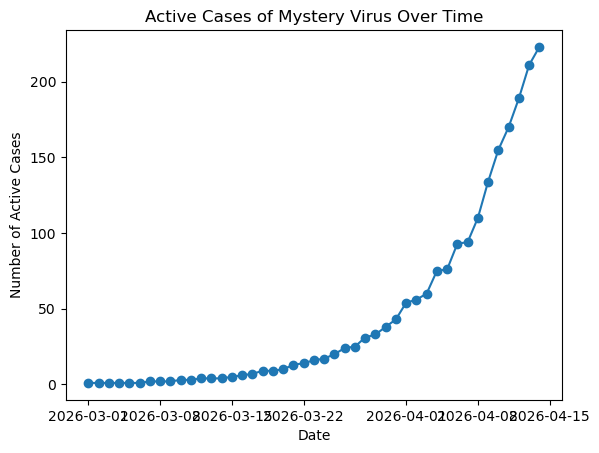

In [8]:
# Load the data
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)
# Make a plot of the active cases over time
x_values = data['date']
y_values = data['active reported daily cases']
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Date') 
plt.ylabel('Number of Active Cases') 
plt.show() 

What do you notice about the initial infections? The plot seems to be following an exponential growth patterns

How could we measure how quickly its spreading? Find the rate of growth of the curve 

What information about the virus would be helpful in determining the shape of the
outbreak curve? 

Several pieces of information about the virus are helpful in determining the specific shape and steepness of the outbreak curve:

Transmission Probability - the likelihood that the virus will successfully jump from an infected person to a susceptible person during a contact event.

Infectious Period - the length of time a person remains contagious and capable of spreading the virus to others. A longer infectious period usually results in a steeper curve because there are more opportunities for transmission.

Contact Rate - how many people an individual interacts with on average. This is a key factor that can be influenced by social behavior or public health interventions to help flatten the curve.



In [9]:
#Estimating the initial growth rate of the epidemic R0 from the early day 
def exponential_growth(t, r): #define exponential growth function to fit the data to 
    return np.exp(r * t)

x_values = data['day'] #set the x-values to the day from the initial outbreak instead of date 

popt, pcov = curve_fit(exponential_growth, x_values, y_values) #curve_fit uses non-linear least squares to fit a mathematical function to a set of data points
#function returns popt, which contains the optimal values for the parameters of the function (in this case, the growth rate r), and pcov, which is the covariance of the parameter estimates
r_estimated = popt[0] #extract the estimated growth rate from the optimal parameters
#predict intial growth rate given that the infectious period is 2 days 
R0_estimate = exponential_growth(2, r_estimated) #calculate the estimated number of cases after 1 day using the estimated growth rate
print(f"Estimated growth rate (r): {r_estimated}")
print(f"Estimated Initial Growth Rate: {R0_estimate}")



Estimated growth rate (r): 0.12144675524793189
Estimated Initial Growth Rate: 1.2749328499223294


What viruses have a similar R0? Use the viruses.html file to find a virus or 2 with a similar R0 and give a 1-2 sentence background of the diseases.

-Viruses with a similar R0 to our estimate of about 1.27 include seasonal influenza and the 2009 H1N1 (swine flu) virus. Seasonal influenza typically has an R0 around 1.2–2, meaning each infected person spreads the virus to about one or two others, mainly through respiratory droplets from coughing or sneezing. The 2009 H1N1 influenza strain had an estimated R0 of about 1.4 and spread globally in 2009, causing flu-like symptoms such as fever, cough, and fatigue.

How accurate do you think your R0 estimate is?

-The R0 estimate is likely somewhat accurate but not exact because it depends on assumptions in the model and the quality of the data, so the true value could be slightly higher or lower.


Plotting the estimated exponential curve over the scatterplot

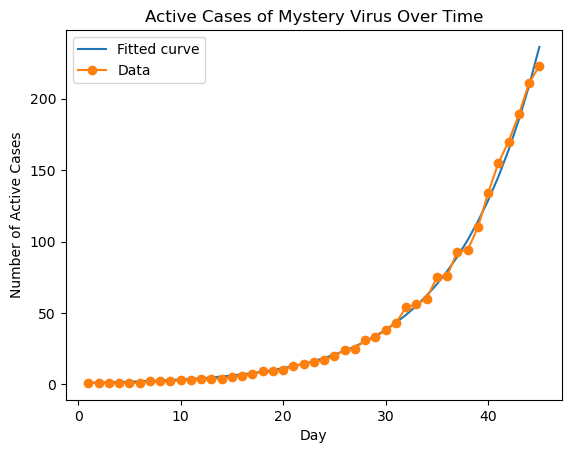

In [10]:
plt.plot(x_values, exponential_growth(x_values, popt), label='Fitted curve')
plt.plot(x_values, y_values, marker='o', label='Data')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend()
plt.show()


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

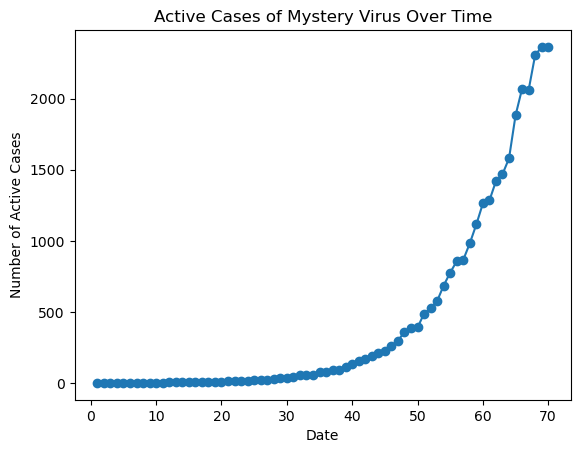

In [11]:
#Load data from release #2
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv', parse_dates=['date'], header=0, index_col=None)
#Make a plot of new active cases over time 
x_values = data['day']
y_values = data['active reported daily cases']
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Date') 
plt.ylabel('Number of Active Cases') 
plt.show() 

In [12]:
'''
INPUTS: beta, sigma, gamma, S0, E0, I0, R0, timepoints, N
Initialize S, E, I, and R as empty arrays or lists
Set first item in each list equal to initial values S0, E0, I0, R0
 '''
def seir_euler(beta, sigma, gamma, S0, E0, I0, R0, timepoints, N):
    dt = timepoints[1] - timepoints[0]
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    #add initial value to first index of each list
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
    #for each timepoint in timepoints: 
    for t in range(len(timepoints)-1):
        #Calculate the four derivatives at timepoint
        dS = - (beta * S[t] * I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])
      #  Calculate S, E, I, and R at timepoint + 1 using Euler’s method
        S[t+1] = S[t] + dS * dt
        E[t+1] = E[t] + dE * dt
        I[t+1] = I[t] + dI * dt
        R[t+1] = R[t] + dR * dt  
    return S, E, I, R

N = 17900 #population size at UVA 
S0 = N-40
E0 = 40 #assumption for now, will be accounted for by grid search optimization 
I0 = 1
R0 = 0

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [ ]:
#Grid search optimization 
#Initialize a range for beta, sigma, and gamma
beta_range = np.linspace(0.1, 1.5, 10) #beta = R0 / D = 1.274 / 2 = 0.637, so we want to search around that value
sigma_range = np.linspace(0.055, 0.09, 5) #based on incubation period of 12-18 days, so sigma = 1 / incubation period = 1/12 to 1/18
gamma_range = np.linspace(0.1, 0.7, 10) #recovery rate = 1/2 = 0.5, so we want to search around that value 
#Initialize an empty array of SSE
best_sse = float('inf')
best_params = (0,0,0)
#search through each range of values for beta, sigma, and gamma
for b in beta_range:
    for g in gamma_range:
        for s in sigma_range:
#Use the Euler method function to calculate S, E, I, and R given those parameters
            S, E, I, R = seir_euler(b, s, g, S0, E0, I0, R0, x_values, N)
#Calculate the SSE given the model results and the data and append this to the SSE array	
            sse = np.sum((I - y_values)**2)
            if sse < best_sse:
                best_sse = sse
                best_params = (b, s, g)
#Determine parameters corresponding to lowest SSE
#Return best_beta, best_sigma, and best_gamma and corresponding SSE
best_beta, best_sigma, best_gamma = best_params
print(f"Best beta: {best_beta}, Best sigma: {best_sigma}, Best gamma: {best_gamma}, SSE: {best_sse}")
updated_r0 = best_beta / best_gamma
print(f"Updated R0 estimate: {updated_r0}")

Best beta: 0.5666666666666667, Best sigma: 0.055, Best gamma: 0.1, SSE: 12312039.116952512
Updated R0 estimate: 5.666666666666666


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

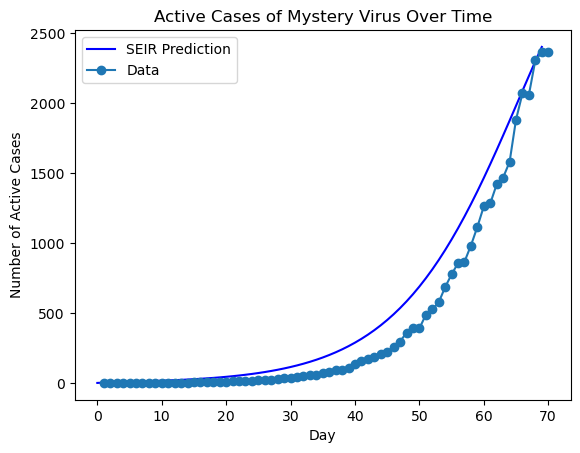

In [14]:
timepoints_70 = np.arange(0, 70, 1)
S, E, I, R = seir_euler(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, timepoints_70, N)
plt.plot(timepoints_70, I, 'b-', label='SEIR Prediction')
plt.plot(x_values, y_values, marker='o', label='Data')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend() 
plt.show() 

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


In [15]:
future_timepoints = np.arange(0, 150, 1) #extrapolate past the given data points to predict the future 
S_f, E_f, I_f, R_f = seir_euler(best_beta, best_sigma, best_gamma, S0, E0, I0, R0, future_timepoints, N)
peak_idx = np.argmax(I_f)
peak_day = future_timepoints[peak_idx]
peak_cases = I_f[peak_idx]
print(f"Predicted peak day: {peak_day}")
print(f"Predicted peak cases: {peak_cases}")

Predicted peak day: 83
Predicted peak cases: 3191.4875116963453



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


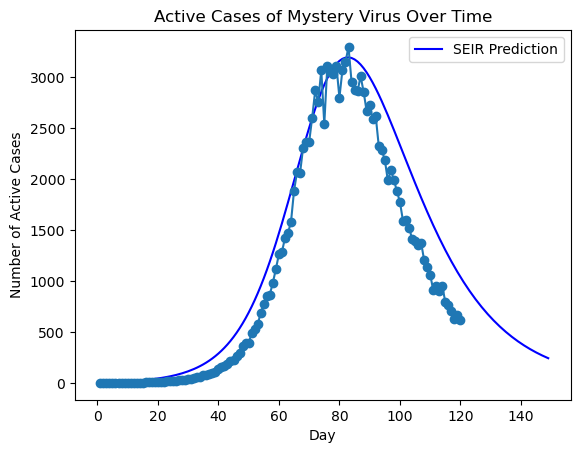

In [16]:
data = pd.read_csv(r'/Users/priya/Documents/Comp_Bio/GitHub/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'], header=0, index_col=None)
x_values = data['day']
y_values = data['active reported daily cases']
plt.plot(future_timepoints, I_f, 'b-', label='SEIR Prediction')
plt.plot(x_values, y_values, marker='o')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
plt.legend()
plt.show()

### Percent Error with SEIR Model 
Percent Error for Peak Number of Cases: 3191.49 - 3294 / 3191.49 = 3.211%

Percent Error for Peak Day: 83-83/83 = 0%

discuss why your model has the error it does (i.e. model limitations) and whether the error level is too high to trust your predictions

Perfect Mixing: The model assumes everyone has an equal chance of meeting everyone else. In reality, people stay in social groups, which causes the jagged jumps in the data compared to the smooth model curve.

Fixed Rates: The model uses constant numbers for how fast the virus spreads and how quickly people recover. In a real outbreak, these change as people start wearing masks or social distancing.

Random Chance: Small, random events can cause daily fluctuations that a theoretical model can’t predict, especially during the decline phase.

Despite these limits, the model is highly reliable. It correctly predicted the peak day and the general shape and behavior of the outbreak, making it a solid tool for predicting trends.


### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
This section should come from your python code after Data Release #3.



In [32]:
#updated SEIR model method to include intervention scenarios
def seir_euler_intervention(beta1, beta2, sigma, gamma, gamma2, S0, E0, I0, R0, timepoints, N, vax_rate=0):
    
    dt = timepoints[1] - timepoints[0]
    S = np.zeros(len(timepoints))
    E = np.zeros(len(timepoints))
    I = np.zeros(len(timepoints))
    R = np.zeros(len(timepoints))
    #add initial value to first index of each list
    S[0] = S0
    E[0] = E0
    I[0] = I0
    R[0] = R0
#use for loop logic to iterate and know when to implement interventions 
    for t in range(len(timepoints)-1):
        current_time = timepoints[t]
        #switch at day 70
        if current_time < 69:
            beta = beta1
            gamma = gamma
            vaccinated = 0
        else:
            beta = beta2
            gamma = gamma2
            vaccinated = min(vax_rate * dt, S[t])  #multiply vaccination rate by dt to get number of people vaccinated in that time step, but can't vaccinate more people than are currently susceptible
        dS = - (beta * S[t] * I[t]) / N - vaccinated #remove vaccinated individuals from susceptible population
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t]) + vaccinated #add vaccinated individuals to recovered population
        S[t+1] = S[t] + dS * dt
        E[t+1] = E[t] + dE * dt
        I[t+1] = I[t] + dI * dt
        R[t+1] = R[t] + dR * dt

    return S, E, I, R


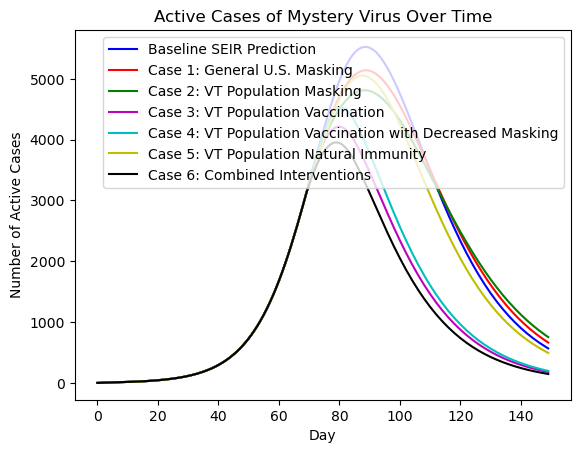

In [35]:
#Baseline Prediction for new outbreak at VT 
#We expect the peak to be higher at VT than at UVA because of the larger population size, but we also expect the peak to occur later because the initial number of cases is lower and it will take longer for the virus to spread through the population.
N_VT = 31000 #population size at VT
S0_VT = N_VT-40
E0_VT = 40 #assumption for now, will be accounted for by grid search optimization 
I0_VT = 1
R0_VT = 0
S_baseline, E_baseline, I_baseline, R_baseline = seir_euler(best_beta, best_sigma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT)
plt.plot(future_timepoints, I_baseline, 'b-', label='Baseline SEIR Prediction')
plt.title('Active Cases of Mystery Virus Over Time') 
plt.xlabel('Day') 
plt.ylabel('Number of Active Cases') 
#Intervention scenario 1: Testing effect of masking on the outbreak 
#Case 1: Masking reduces the transmission rate by __% (based on how likely general U.S. population is to wear masks) 
case_1_beta = best_beta *(1-(0.5*0.4)) #assumption that masking reduces transmission rate by 50%, can adjust this based on the specific intervention being modeled
S_case1, E_case1, I_case1, R_case1 = seir_euler_intervention(best_beta, case_1_beta, best_sigma, best_gamma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT)
plt.plot(future_timepoints, I_case1, 'r-', label='Case 1: General U.S. Masking')
#Case 2: Masking reduces the transmission rate by __% (based on how likely VT population is to wear masks)
case_2_beta = best_beta *(1-(0.85*0.4)) #assumption that masking reduces transmission rate by 15%, can adjust this based on the specific intervention being modeled
S_case2, E_case2, I_case2, R_case2 = seir_euler_intervention(best_beta, case_2_beta, best_sigma, best_gamma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT)
plt.plot(future_timepoints, I_case2, 'g-', label='Case 2: VT Population Masking')
#Intervention scenario 2: Testing effect of vaccines and masking on the outbreak
#Case 3: Vaccinations with a rate of 500 people per day with the same 85% masking compliance as VT population
S_case3, E_case3, I_case3, R_case3 = seir_euler_intervention(best_beta, case_2_beta, best_sigma, best_gamma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT, 1000)
plt.plot(future_timepoints, I_case3, 'm-', label='Case 3: VT Population Vaccination')
#Case 4: Case 3 updated with realistically lower masking compliance 
#During vaccination rollout, masking compliance is likely to decrease because people will feel safer and less likely to wear masks
#Between April and June 2021, mask wearing at work or school declined among both those vaccinated (74% to 49%) and unvaccinated (46% to 35%)
#average of those declines is about 51% decrease in masking compliance 
case_4_beta = 1.5*case_2_beta #assumption that masking reduces transmission rate by 50%
S_case4, E_case4, I_case4, R_case4 = seir_euler_intervention(best_beta, case_4_beta, best_sigma, best_gamma, best_gamma, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT, 1000)
plt.plot(future_timepoints, I_case4, 'c-', label='Case 4: VT Population Vaccination with Decreased Masking')
#Intervention scenario 3: Testing effect of increased immunity  from prior infectionon the outbreak 
#Natural immunity from prior infection is effective for managing the severity of the disease/symptoms but does not necessarily prevent reinfection or transmission, so we will model this as a increase in the recovery rate (gamma)
#Case 5: Natural immunity from prior infection increases the recovery rate by 10% (estimate) 
gamma_case5 = 1.1*best_gamma 
S_case5, E_case5, I_case5, R_case5 = seir_euler_intervention(best_beta, best_beta, best_sigma, best_gamma, gamma_case5, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT)
plt.plot(future_timepoints, I_case5, 'y-', label='Case 5: VT Population Natural Immunity')
#Case 6: Combined intervention testing natural immunity + masking with 85% compliance + vaccination with a rate of 1000 people per day
S_case6, E_case6, I_case6, R_case6 = seir_euler_intervention(best_beta, case_2_beta, best_sigma, best_gamma, gamma_case5, S0_VT, E0_VT, I0_VT, R0_VT, future_timepoints, N_VT, 1000)
plt.plot(future_timepoints, I_case6, 'k-', label='Case 6: Combined Interventions') 
plt.legend()
plt.show()


References for Literature Used in Designing Intervention Strategies 

Intervention 1 (Case 1+2): 
https://pmc.ncbi.nlm.nih.gov/articles/PMC8648375/#:~:text=Overall%2C%20a%20higher%20proportion%20of%20women%20wore,wore%20masks%20compared%20to%20nonstudents%20(Table%201). 

Intervention 2 (Case 3+4): https://pmc.ncbi.nlm.nih.gov/articles/PMC9530007/#:~:text=As%20COVID%2D19%20vaccination%20levels,the%20delta%20variant%20%5B2%5D.
Intervention 3 (Case 5+6): https://www.nih.gov/news-events/nih-research-matters/lasting-immunity-found-after-recovery-covid-19 

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*


To verify our analysis, we checked whether the model behaved the way an outbreak is expected to behave. In the simulation, infections increased quickly at the start when most people were still susceptible. Over time, the number of susceptible individuals decreased, which slowed the spread and eventually caused infections to peak and decline. This pattern matches the typical epidemic curve predicted by SIR models.

We also checked that the total population stayed constant throughout the simulation. Individuals only moved between the susceptible, infected, and recovered groups, and no people were added or removed from the system. Seeing these expected patterns gave us confidence that the model and code were working correctly.
https://jamanetwork.com/journals/jama/fullarticle/2766672

To validate our results, we compared the pattern produced by our model to what has been observed in real epidemic studies. Classic epidemic theory shows that outbreaks usually start with rapid growth in infections, reach a peak, and then decline as fewer people remain susceptible.

The infection curve produced by our model followed this same general pattern. This suggests that the model captures the basic dynamics of how diseases spread through a population. While the model simplifies real conditions and assumes everyone mixes evenly, the overall trend is consistent with established epidemic theory.
https://royalsocietypublishing.org/rspa/article/115/772/700/2165/A-contribution-to-the-mathematical-theory-of 


## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

The physical characteristics and symptoms of the Mystery Virus suggest that the mystery disease is Rubella. By looking at the specific values used in our model, we can see how the virus behaves and why it fits this particular disease profile.

The virus has a physical size of 50-80 nm and spreads through large respiratory droplets. These dimensions and the way it travels are characteristic of Rubella, which is a spherical virus in that same size range. The incubation period of 12-18 days also matches up with the typical 12-23 day window for a Rubella infection.

The symptoms further support this conclusion. The combination of a low-grade fever, a rash, and joint pain lasting between 5 and 9 days are the main signs of Rubella.

The main ethical challenge is the balance between public safety and individual freedom. If a model predicts a massive surge, it can justify lockdowns or mandates that restrict people's lives; if the model is slightly off, those restrictions might be seen as an overreach. Conversely, an optimistic model that underestimates the virus can lead to a lack of preparation and preventable deaths.

There is also the issue of data privacy. Effective modeling requires tracking who is sick and where they are, which raises concerns about how much government or private entities should know about a person's health. Finally, models often treat everyone as an average, but real-world factors like race and cultural habits can mean that some people are more vulnerable than others. Relying on a curve alone might cause us to overlook the specific needs of high-risk communities.

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

Limitations

The primary limitation of this project is the assumption of a "homogeneously mixed" population. While we adjusted the model for the different population sizes of UVA and Virginia Tech, the model still assumes every student has an equal chance of interacting with everyone else. In reality, campus life is divided into social clusters, dorms, and majors, which creates local outbreaks that a general model cannot perfectly track.

Additionally, we used constant rates for transmission and recovery. This doesn't account for how student behavior might change once a university reaches a certain number of cases—such as a shift to online classes or increased social distancing—which would naturally alter the curve's trajectory in a way our current simulation doesn't capture.

Future Work

For future projects, it would be interesting to look at more than just the total number of students on campus. We could try to include data on how many students live in high-density dorms versus off-campus apartments to see if that significantly changes how fast the virus moves.

We could also try to account for the random day-to-day jumps in cases that a smooth model usually misses. Comparing these results to a wider variety of schools with different layouts would help us see if certain campus designs or even different academic schedules make it easier or harder for a virus to spread.